<a href="https://colab.research.google.com/github/HleBBondar/amazon-sales-analytics-ab-testing/blob/main/Amazon_Statistical_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_3116/3705007555.py:16: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Amazon_Sale_Report.csv')


             DESCRIPTIVE STATISTICS               
Control Group (No Promotion):
  - Sample Size (N)  : 35,000
  - Average Value (AOV): $623.26
  - Std Deviation (SD) : $268.59

Test Group (Used Promotion):
  - Sample Size (N)  : 78,701
  - Average Value (AOV): $680.91
  - Std Deviation (SD) : $268.06

               HYPOTHESIS TESTING                 
T-statistic : -33.4298
p-value     : 5.105260486243844e-243
--------------------------------------------------
CONCLUSION: STATISTICALLY SIGNIFICANT DIFFERENCE DETECTED!
Result: Reject the Null Hypothesis (H0).
Business Meaning: Marketing promotions have a genuine, non-random effect
                  on increasing the Average Order Value (AOV).



/tmp/ipykernel_3116/3705007555.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


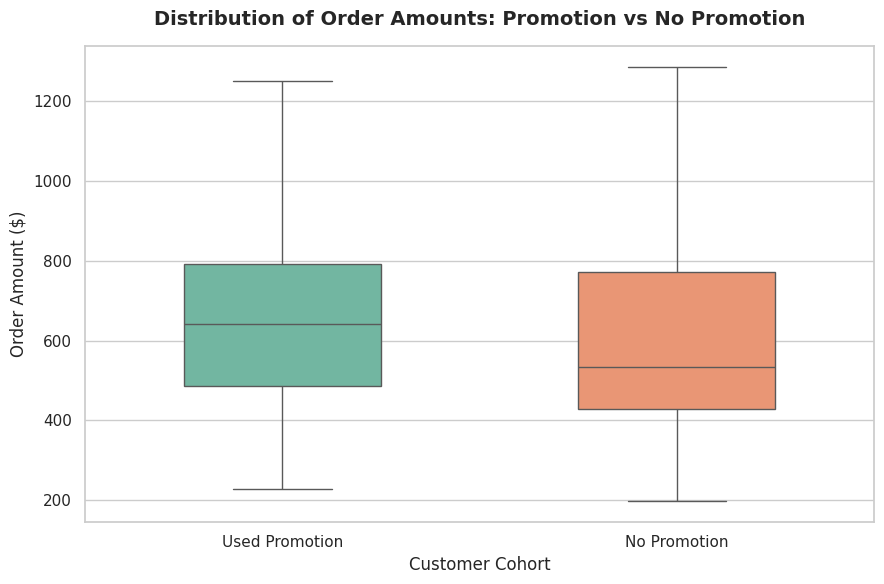

In [4]:
"""
Amazon Marketing Campaign Efficiency Analysis
Author: Hleb Bondar
Description: This script performs statistical inference (Welch's t-test)
             to validate if marketing promotions statistically affect
             the Average Order Value (AOV).
"""

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading the dataset
df = pd.read_csv('Amazon_Sale_Report.csv')

# 2. Data Cleaning: Filtering out non-positive order amounts and quantities
df_clean = df[(df['Amount'] > 0) & (df['Qty'] > 0)].copy()

# 3. Feature Engineering: Defining Control and Test groups based on coupon usage
# If 'promotion-ids' is null, empty, or equals 'No promotion', it's Control, else Test.
df_clean['is_promo'] = np.where(
    df_clean['promotion-ids'].isna() |
    (df_clean['promotion-ids'] == '') |
    (df_clean['promotion-ids'] == 'No promotion'),
    'No Promotion', 'Used Promotion'
)

# 4. Spliting the data into independent samples for AOV comparison
group_control = df_clean[df_clean['is_promo'] == 'No Promotion']['Amount']
group_test = df_clean[df_clean['is_promo'] == 'Used Promotion']['Amount']

# 5. Descriptive Statistics Summary
print("==================================================")
print("             DESCRIPTIVE STATISTICS               ")
print("==================================================")
print(f"Control Group (No Promotion):")
print(f"  - Sample Size (N)  : {len(group_control):,}")
print(f"  - Average Value (AOV): ${group_control.mean():.2f}")
print(f"  - Std Deviation (SD) : ${group_control.std():.2f}\n")

print(f"Test Group (Used Promotion):")
print(f"  - Sample Size (N)  : {len(group_test):,}")
print(f"  - Average Value (AOV): ${group_test.mean():.2f}")
print(f"  - Std Deviation (SD) : ${group_test.std():.2f}")
print("==================================================\n")

# 6. Hypothesis Testing: Independent Two-Sample Welch's T-Test
# equal_var=False is strictly applied as sample sizes and variances differ.
t_stat, p_value = stats.ttest_ind(group_control, group_test, equal_var=False)

print("==================================================")
print("               HYPOTHESIS TESTING                 ")
print("==================================================")
print(f"T-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value}")
print("--------------------------------------------------")

# 7. Statistical Decision & Interpretation
alpha = 0.05  # Significance level

if p_value < alpha:
    print("CONCLUSION: STATISTICALLY SIGNIFICANT DIFFERENCE DETECTED!")
    print(f"Result: Reject the Null Hypothesis (H0).")
    print("Business Meaning: Marketing promotions have a genuine, non-random effect")
    print("                  on increasing the Average Order Value (AOV).")
else:
    print("CONCLUSION: NO STATISTICALLY SIGNIFICANT DIFFERENCE.")
    print(f"Result: Fail to reject the Null Hypothesis (H0).")
    print("Business Meaning: The observed difference in AOV is likely due to statistical noise.")
    print("                  Promotions do not yield a meaningful lift in basket size.")
print("==================================================\n")

# 8. Data Visualization:
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

sns.boxplot(
    x='is_promo',
    y='Amount',
    data=df_clean,
    showfliers=False,
    palette='Set2',
    width=0.5
)

plt.title('Distribution of Order Amounts: Promotion vs No Promotion', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Cohort', fontsize=12)
plt.ylabel('Order Amount ($)', fontsize=12)

plt.tight_layout()
plt.savefig('promotion_impact_boxplot.png', dpi=300)
plt.show()